In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/florida-real-estate-sold-dataset-2026/florida_real_estate_sold_properties_ultimate.csv")
print(df.shape)
print('Columns:\n', df.columns.tolist())
print('\nInfo:\n', df.info())
print('\nNull Values:\n', df.isnull().sum())

(10893, 14)
Columns:
 ['type', 'sub_type', 'listPrice', 'lastSoldPrice', 'sqft', 'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built', 'zip', 'sanitized_text']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10893 entries, 0 to 10892
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             10893 non-null  object 
 1   sub_type         2476 non-null   object 
 2   listPrice        10881 non-null  float64
 3   lastSoldPrice    10893 non-null  int64  
 4   sqft             10136 non-null  float64
 5   stories          9161 non-null   float64
 6   beds             10217 non-null  float64
 7   baths            10254 non-null  float64
 8   baths_full       10210 non-null  float64
 9   baths_full_calc  10210 non-null  float64
 10  garage           7306 non-null   float64
 11  year_built       10215 non-null  float64
 12  zip              10891 non-null  float64
 13  sanit

In [8]:
# Cleaning of data
df['garage'] = df['garage'].fillna(0)
df['sub_type'] = df['sub_type'].fillna('Standard')

df['sqft'] = df.groupby('type')['sqft'].transform(lambda x: x.fillna(x.median()))
df['beds'] = df.groupby('type')['beds'].transform(lambda x: x.fillna(x.median()))
df['baths'] = df.groupby('type')['baths'].transform(lambda x: x.fillna(x.median()))
df['year_built'] = df.groupby('type')['year_built'].transform(lambda x: x.fillna(x.median()))

df.dropna(subset=['zip', 'listPrice'], inplace=True)

In [9]:
# Feature Engineering
df['property_age'] = 2026 - df['year_built']
df['price_per_sqft'] = df['lastSoldPrice'] / df['sqft']
df['sold_ratio'] = df['lastSoldPrice'] / df['listPrice']

In [14]:
# Check the health of our new columns
print('--- Clean Columns ---')
print(df[['property_age', 'price_per_sqft', 'sold_ratio']].describe())
print('\nRemaining Nulls:', df.isnull().sum())

--- Clean Columns ---
       property_age  price_per_sqft    sold_ratio
count  10879.000000    10879.000000  10879.000000
mean      29.004228      273.321089      0.981148
std       22.643158      720.430632      2.211444
min       -1.000000        0.006717      0.000701
25%        8.000000      166.843545      0.937502
50%       29.000000      214.736842      0.971429
75%       44.000000      296.296296      1.000000
max      326.000000    70000.000000    230.000000

Remaining Nulls: type                  0
sub_type              0
listPrice             0
lastSoldPrice         0
sqft                  0
stories            1729
beds                639
baths                 0
baths_full          681
baths_full_calc     681
garage                0
year_built            0
zip                   0
sanitized_text       16
property_age          0
price_per_sqft        0
sold_ratio            0
dtype: int64


In [15]:
# Outliers removal
df = df[df['property_age'] >= 0]
df = df[(df['sold_ratio'] >=0.5) & (df['sold_ratio'] <= 1.5)]
df = df[(df['price_per_sqft'] > 10) & (df['price_per_sqft'] < 5000)]
df['sanitized_text'] = df['sanitized_text'].fillna('None')
df['stories'] = df['stories'].fillna(1) # Defaulting to single story

print("--- Final Clean Descriptive Stats ---")
print(df[['property_age', 'price_per_sqft', 'sold_ratio']].describe())

--- Final Clean Descriptive Stats ---
       property_age  price_per_sqft    sold_ratio
count  10350.000000    10350.000000  10350.000000
mean      28.928986      278.247153      0.961773
std       23.157230      234.960652      0.055418
min        0.000000       10.037060      0.500250
25%        7.000000      173.834793      0.941176
50%       27.000000      219.614159      0.972818
75%       45.000000      303.218104      1.000000
max      326.000000     4016.393443      1.362282


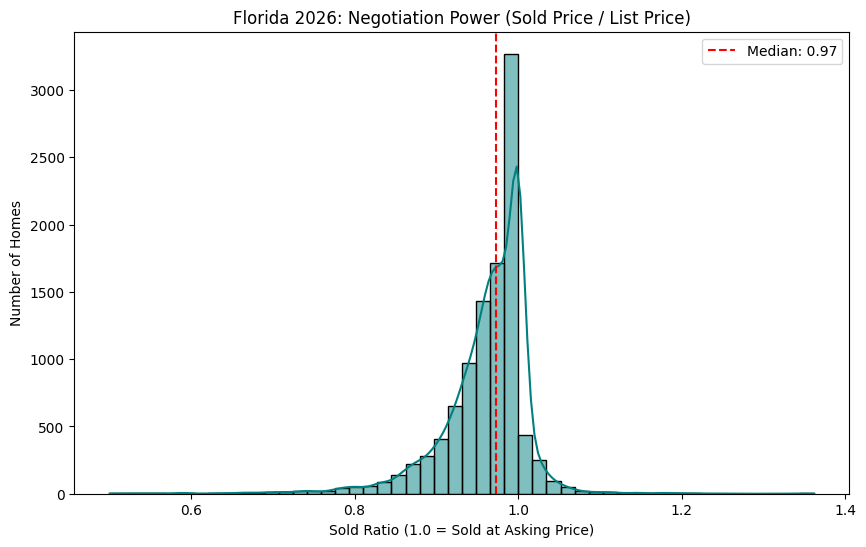

In [16]:
# Visuals
plt.figure(figsize=(10,6))

sns.histplot(df['sold_ratio'], bins=50, kde=True, color='teal')
plt.axvline(df['sold_ratio'].median(), color='red', linestyle='--', label=f'Median: {df["sold_ratio"].median():.2f}')
plt.title('Florida 2026: Negotiation Power (Sold Price / List Price)')
plt.xlabel('Sold Ratio (1.0 = Sold at Asking Price)')
plt.ylabel('Number of Homes')
plt.legend()
plt.show()

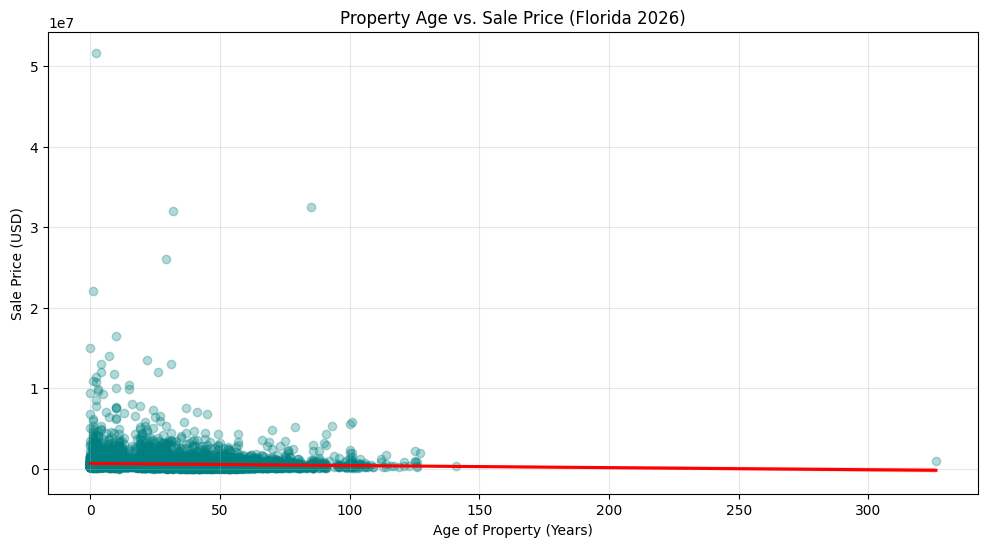

In [17]:
# Age vs Value

plt.figure(figsize=(12,6))
sns.regplot(data=df, x='property_age', y='lastSoldPrice', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Property Age vs. Sale Price (Florida 2026)')
plt.xlabel('Age of Property (Years)')
plt.ylabel('Sale Price (USD)')
plt.grid(alpha=0.3)
plt.show()

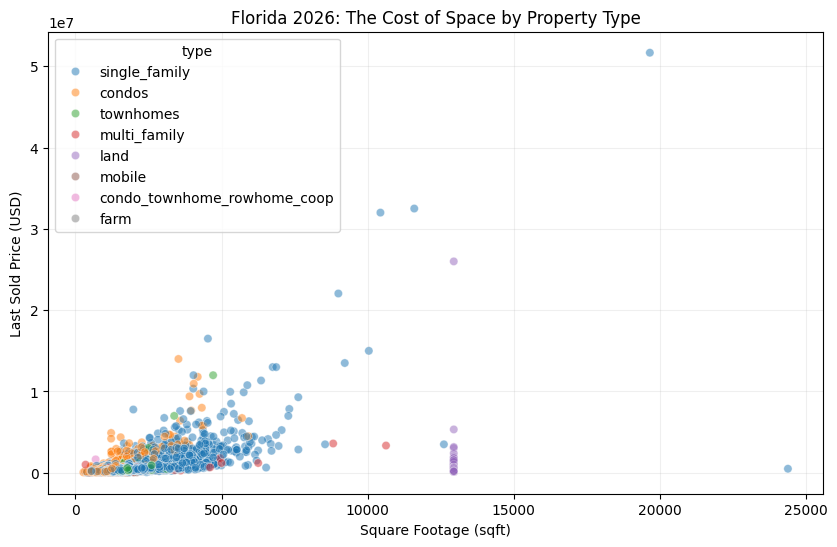

In [18]:
# Space Efficency
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sqft', y='lastSoldPrice', hue='type', alpha=0.5)
plt.title('Florida 2026: The Cost of Space by Property Type')
plt.xlabel('Square Footage (sqft)')
plt.ylabel('Last Sold Price (USD)')
plt.grid(alpha=0.2)
plt.show()

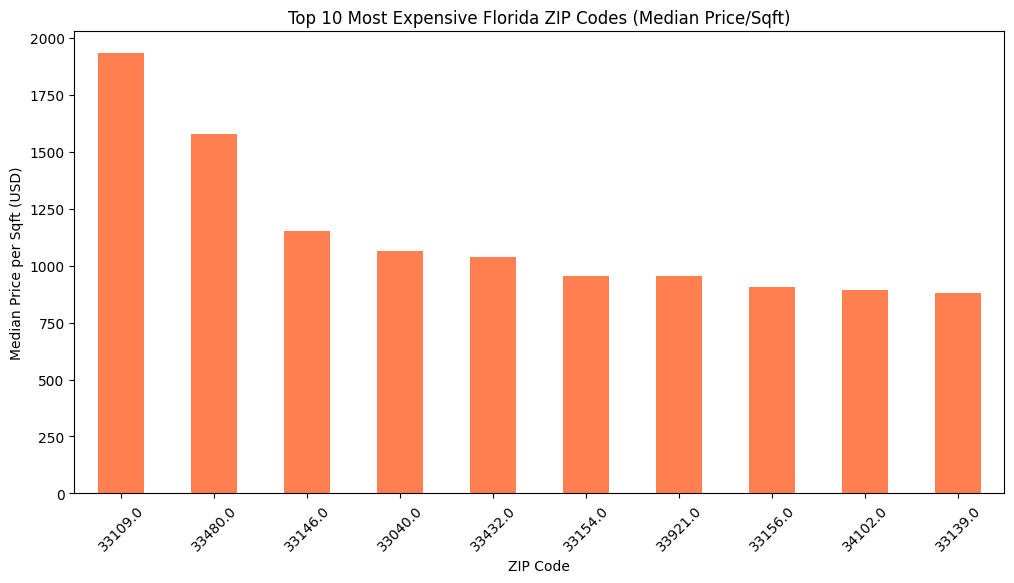

Top 5 ZIP Codes by Price/Sqft:
zip
33109.0    1931.867713
33480.0    1576.681479
33146.0    1153.576815
33040.0    1064.356773
33432.0    1036.268690
Name: price_per_sqft, dtype: float64


In [19]:
# Group by ZIP and find the Median Price per Sqft
zip_stats = df.groupby('zip')['price_per_sqft'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
zip_stats.plot(kind='bar', color='coral')

plt.title('Top 10 Most Expensive Florida ZIP Codes (Median Price/Sqft)')
plt.ylabel('Median Price per Sqft (USD)')
plt.xlabel('ZIP Code')
plt.xticks(rotation=45)
plt.show()

print("Top 5 ZIP Codes by Price/Sqft:")
print(zip_stats.head(5))

📊 Key Insights: Florida Real Estate (2026)
-------------------------------------------

-   **The Negotiation Baseline:** The market is remarkably stable. With a **median Sold Ratio of 0.97**, buyers are typically securing only a **3% discount** off the list price. The large "hump" at 1.0 indicates that a high volume of properties sell exactly at the asking price.

-   **Depreciation vs. Vintage:** The regression analysis shows a steady decline in value as properties age, but the relationship is non-linear. New constructions (0--5 years) command a significant premium, while homes older than 50 years show higher price volatility, likely due to renovations.

-   **Luxury Hubs:** Location is the primary driver of value over physical size. **ZIP Code 33109** is the clear luxury leader, with a median price per square foot exceeding **USD 1,930**---nearly **7x higher** than the dataset's average (USD 278).

-   **Space Efficiency:** Single-family homes dominate the high-end market in terms of total price, but **Condos and Townhomes** often show a higher density of value (price per sqft) in coastal areas.

-   **Outlier Resilience:** Initial raw data contained extreme errors (e.g., sold ratios of 230x). Post-cleaning, the dataset moved from a chaotic state to a realistic distribution, making it viable for predictive modeling.